In [30]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.metrics import recall_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import shap
import joblib
from mpl_toolkits.mplot3d import Axes3D

# Préparation des données

## Chargement et première inspection

In [49]:
# Chargement des données
data_nba=pd.read_csv("../data/nba_logreg.csv")
df=data_nba.copy()

In [51]:
# Taille du dataset
print(df.shape)

(1340, 21)


In [52]:
# Apperçu des premières lignes
display(df.head())

,Name,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,...,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,25.0,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0.0
1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,23.5,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0.0
2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,24.4,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0.0
3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,22.6,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1.0
4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,0.0,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1.0


In [53]:
# Vérification des doublons et suppression
df.duplicated().any()


np.True_

In [54]:
df=df.drop_duplicates()

In [55]:
# Info globales
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1339
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         1328 non-null   object 
 1   GP           1328 non-null   int64  
 2   MIN          1328 non-null   float64
 3   PTS          1328 non-null   float64
 4   FGM          1328 non-null   float64
 5   FGA          1328 non-null   float64
 6   FG%          1328 non-null   float64
 7   3P Made      1328 non-null   float64
 8   3PA          1328 non-null   float64
 9   3P%          1318 non-null   float64
 10  FTM          1328 non-null   float64
 11  FTA          1328 non-null   float64
 12  FT%          1328 non-null   float64
 13  OREB         1328 non-null   float64
 14  DREB         1328 non-null   float64
 15  REB          1328 non-null   float64
 16  AST          1328 non-null   float64
 17  STL          1328 non-null   float64
 18  BLK          1328 non-null   float64
 19  TOV        

On peut constater que toutes les données sont numériques exceptés les Noms. 

Il y a des données manquantes uniquement sur les pourcentage de réussite à 3 points 

## Gestion des valeurs manquantes

In [6]:
df.isna().sum()

Name            0
GP              0
MIN             0
PTS             0
FGM             0
FGA             0
FG%             0
3P Made         0
3PA             0
3P%            11
FTM             0
FTA             0
FT%             0
OREB            0
DREB            0
REB             0
AST             0
STL             0
BLK             0
TOV             0
TARGET_5Yrs     0
dtype: int64

In [7]:
# Imputation des valeurs manquantes par la valeur 0, car elles ne concernent uniquement que les joueurs qui n'ont pas effectué de tir à 3 pts
df.fillna(0,inplace=True)

# Analyse Exploratoire des Données

## Statistiques decriptivees globales

In [8]:
display(df.describe())

,GP,MIN,PTS,FGM,FGA,FG%,3P Made,3PA,3P%,FTM,FTA,FT%,OREB,DREB,REB,AST,STL,BLK,TOV,TARGET_5Yrs
count,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,60.414179,17.624627,6.801493,2.629104,5.885299,44.169403,0.247612,0.779179,19.149627,1.297687,1.821940,70.300299,1.009403,2.025746,3.034478,1.550522,0.618507,0.368582,1.193582,0.620149
std,17.433992,8.307964,4.357545,1.683555,3.593488,6.137679,0.383688,1.061847,16.051861,0.987246,1.322984,10.578479,0.777119,1.360008,2.057774,1.471169,0.409759,0.429049,0.722541,0.485531
min,11.000000,3.100000,0.700000,0.300000,0.800000,23.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.200000,0.300000,0.000000,0.000000,0.000000,0.100000,0.000000
25%,47.000000,10.875000,3.700000,1.400000,3.300000,40.200000,0.000000,0.000000,0.000000,0.600000,0.900000,64.700000,0.400000,1.000000,1.500000,0.600000,0.300000,0.100000,0.700000,0.000000
50%,63.000000,16.100000,5.550000,2.100000,4.800000,44.100000,0.100000,0.300000,22.200000,1.000000,1.500000,71.250000,0.800000,1.700000,2.500000,1.100000,0.500000,0.200000,1.000000,1.000000
75%,77.000000,22.900000,8.800000,3.400000,7.500000,47.900000,0.400000,1.200000,32.500000,1.600000,2.300000,77.600000,1.400000,2.600000,4.000000,2.000000,0.800000,0.500000,1.500000,1.000000
max,82.000000,40.900000,28.200000,10.200000,19.800000,73.700000,2.300000,6.500000,100.000000,7.700000,10.200000,100.000000,5.300000,9.600000,13.900000,10.600000,2.500000,3.900000,4.400000,1.000000


***Interpretation*** : 

Les statistiques descriptives montrent que l’échantillon est majoritairement composé de joueurs ayant joué entre 47 et 77 matchs, avec une médiane autour de 63.
Cela confirme que la plupart des joueurs du dataset sont utilisés régulièrement par leurs équipes.

Les variables comme PTS, MIN, FGM ou FGA présentent une dispersion importante (écarts-types élevés), ce qui indique une forte variabilité de profils entre joueurs : certains sont très impliqués offensivement, d’autres beaucoup moins.

Le taux de réussite au tir (FG%) est relativement concentré autour de 44 %, ce qui est cohérent avec des standards NBA.

Les valeurs maximales de certaines statistiques (3P% = 100 %, FT% = 100 %) correspondent à des joueurs qui ont tenté très peu de tirs. Par exemple un joeur qui tente un tir et qui le reussi aura 100% de reussite. 

Nous pouvons également constater que les données n'ont pas la même échelle, nous avons certaines variables dont la valeur maximale est 2 et d'autres 100.
Une normalisation sera nécessaire pour l'utilisation des modèles linéaires.

# Analyse univariée

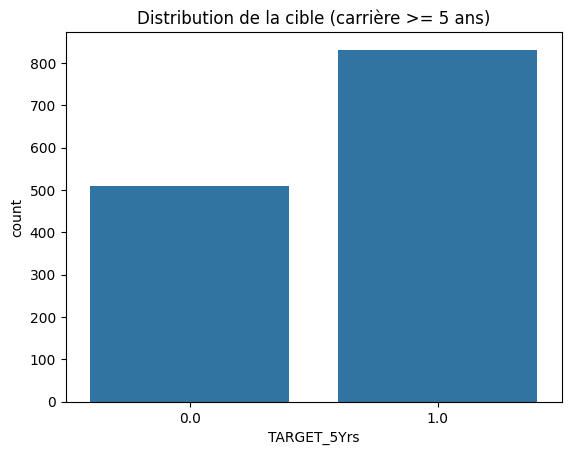

TARGET_5Yrs
1.0    831
0.0    509
Name: count, dtype: int64


In [9]:
# Distribution de la cible
sns.countplot(data=df, x="TARGET_5Yrs")
plt.title("Distribution de la cible (carrière >= 5 ans)")
plt.show()

print(df["TARGET_5Yrs"].value_counts())

***Interpretation:*** 

La distribution de la cible montre que 62 % des joueurs ont une carrière supérieure à 5 ans contre 38% qui ont une carrière plus courte. 
Cette légère asymétrie indique un déséquilibre modéré, mais pas suffisamment important pour nécessiter un traitement lourd (type oversampling).

D’un point de vue métier, cela reflète la réalité. La majorité des joueurs NBA réussissent à s’installer plusieurs saisons, mais une part non négligeable ne dépasse pas les 5 ans.

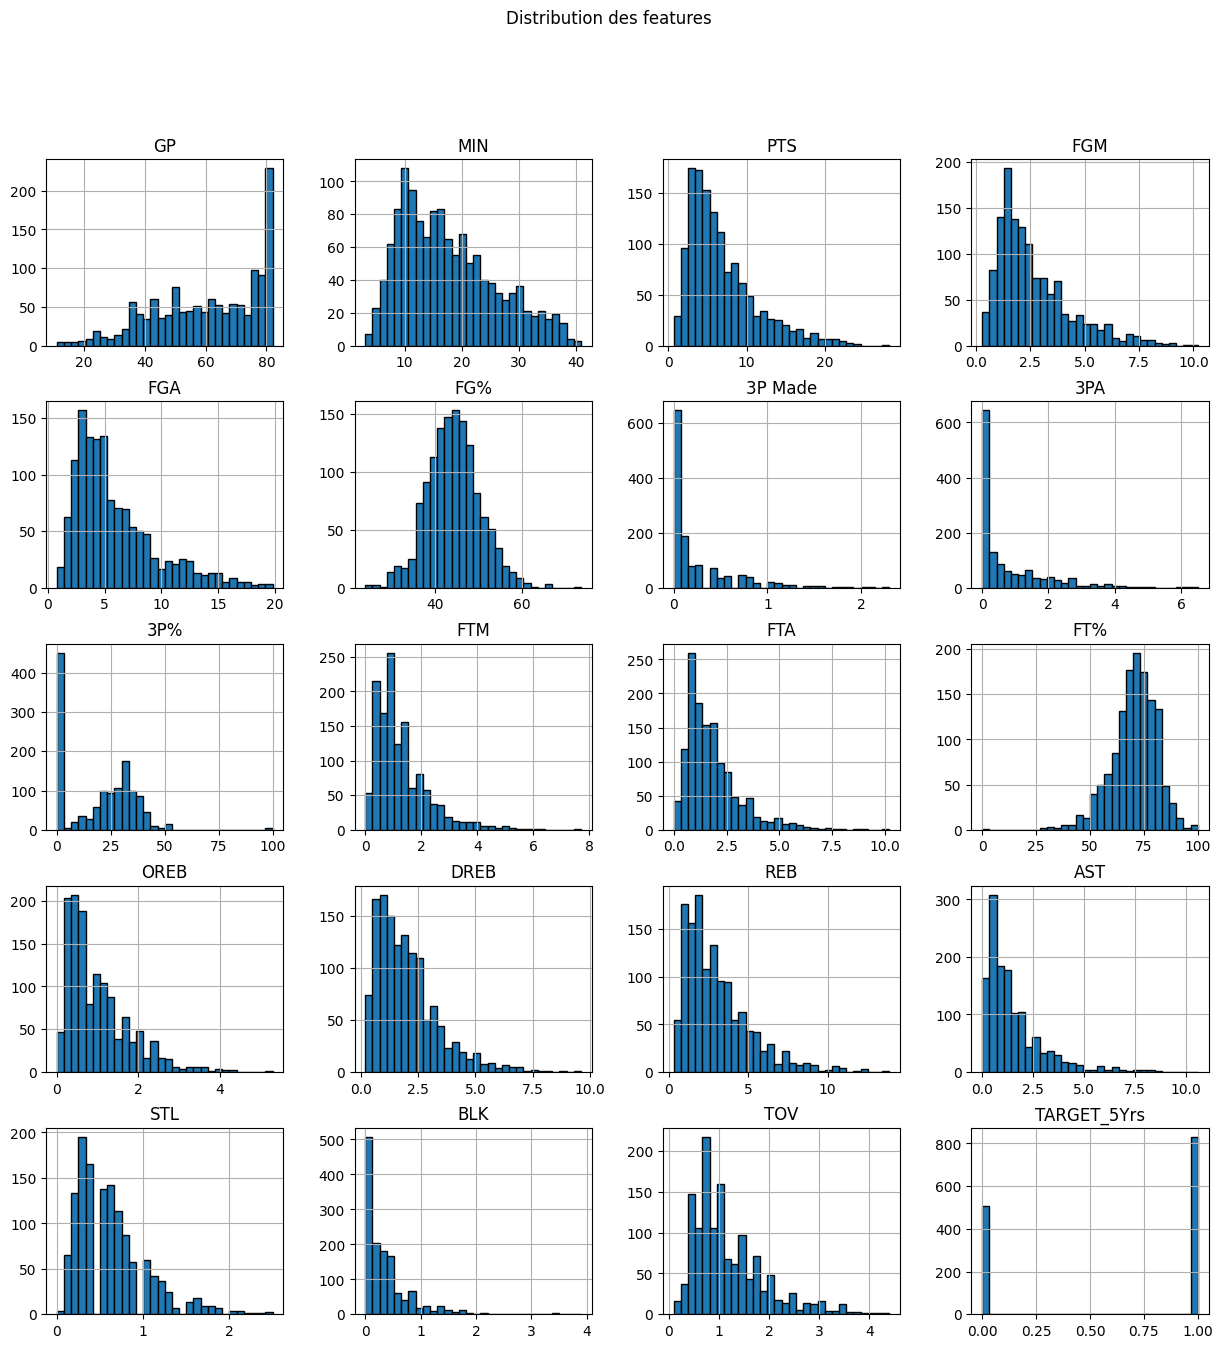

In [10]:
# Distribution des différentes variables
df.hist(figsize=(15, 15), bins=30, edgecolor='black')
plt.suptitle("Distribution des features")
plt.show()

***Interpretation:***

Les distributions des statistiques confirment une forte hétérogénéité entre joueurs.
On observe par exemple que :

- la majorité marque moins de 10 points par match,
- le nombre de minutes jouées est très concentré entre 10 et 25 minutes,
- les statistiques de tirs à 3 points (3PA, 3P%) montrent que plusieurs joueurs ne tentent presque jamais de tirs longue distance.

Ces éléments indiquent que notre dataset couvre une diversité de rôles : shooters, intérieurs dominants, joueurs de rotation, rookies avec peu de minutes, etc.

Cela confirme que les relations avec la cible risquent d’être non linéaires, ce qui va guider le choix des modèles par la suite.

Les données reflètent la réalité du terrain. 

Nous pouvons noté quelques outliers mais, ils ne sont pas anormaux, ils sont plutôt important

# Analyse multivariée (matrice de corrélation)

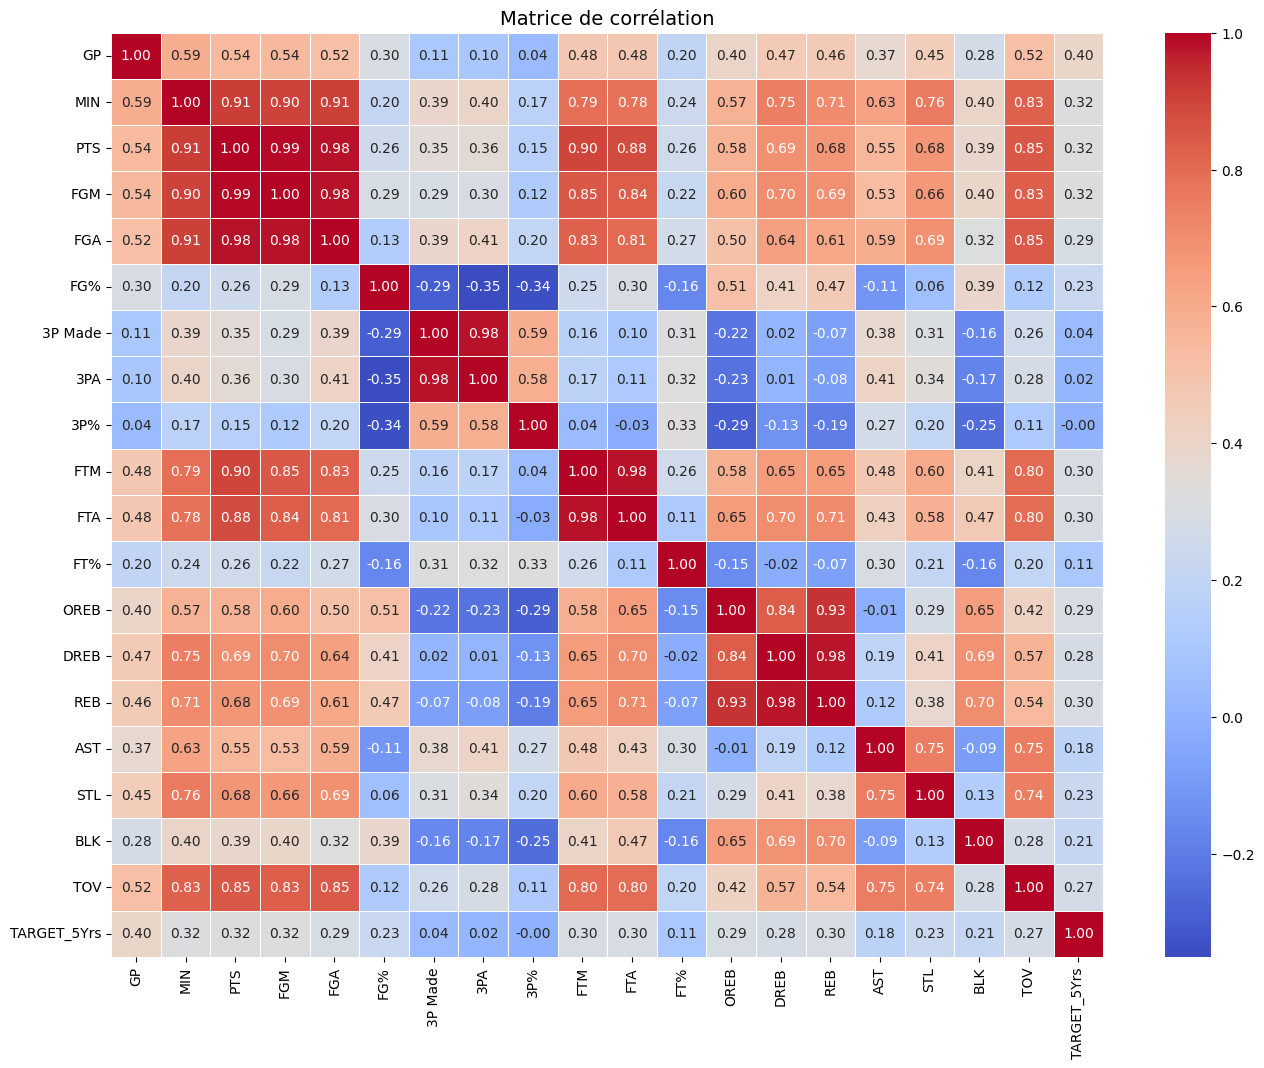

In [11]:
import seaborn as sns

plt.figure(figsize=(16, 12))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrice de corrélation", fontsize=14)
plt.show()

In [12]:
# Top variables corrélées avec la cible
corr_cible=corr["TARGET_5Yrs"].sort_values(ascending=False)
corr_cible

TARGET_5Yrs    1.000000
GP             0.396833
MIN            0.317805
FGM            0.317594
PTS            0.315981
REB            0.299406
FTM            0.296841
FTA            0.296089
OREB           0.293307
FGA            0.292660
DREB           0.284677
TOV            0.272348
STL            0.229811
FG%            0.227134
BLK            0.210114
AST            0.175353
FT%            0.106706
3P Made        0.036619
3PA            0.018110
3P%           -0.000004
Name: TARGET_5Yrs, dtype: float64

***Interpretation:***

Les quatres meilleurs corrélations sont le nombre de match joué, le nombre de minute joué, le nombre de tirs reussis et le nombre points marqué. 
Cela semble cohérent, car un joueur qui dure dans le temps joue beaucoup de matchs (plus un joueur est solide plus il joue : moins de blessures). 
Les joueurs qui joue le plus de minutes sont les plus importants, ce sont les titulaires (ils sont talentueux,reçoivent plus d'opportunités), donc reste plus longtemps dans la ligue.
Les joueurs plus offensifs sont plus succeptibles d'être conservés et de rester


Les rebonds et l'activité physique sont également important car les joueurs capables d’apporter physiquement (rebonds, activité intérieure) ont :un rôle plus stable,un profil plus durable,une capacité d’adaptation plus forte.

Les pourcentages aux tirs sont peu corrélés
Cela revèle que l’efficacité au tir n’est pas un bon prédicteur de longévité en NBA, contrairement au volume de jeu et au rôle global dans l’équipe.
Les pourcentages influencent la qualité du joueur, mais la longévité dépend plus du rôle, de la capacité à jouer et à contribuer, que de l’efficacité pure.

Le tir à 3 points n’explique presqu'en rien la longevité d'un joueur en NBA.


Les variables les plus fortement corrélées avec la longévité NBA sont les volumes de jeu (GP, MIN), les capacité offensives offensifs (FGM, PTS,FTM,FTA,FGA) et les contributions physiques (REB, OREB, DREB).
À l’inverse, les pourcentages aux tirs (FG%, 3P%, FT%) montrent une corrélation faible, ce qui indique que la longévité est davantage liée au rôle et à l’implication sur le terrain qu’à l'efficacité pure.
Ces observations orientent notre modélisation vers des modèles capables de capturer des interactions non linéaires entre ces variables, tels que Random Forest et XGBoost.


# Comparaison prometteurs vs non-prometteurs

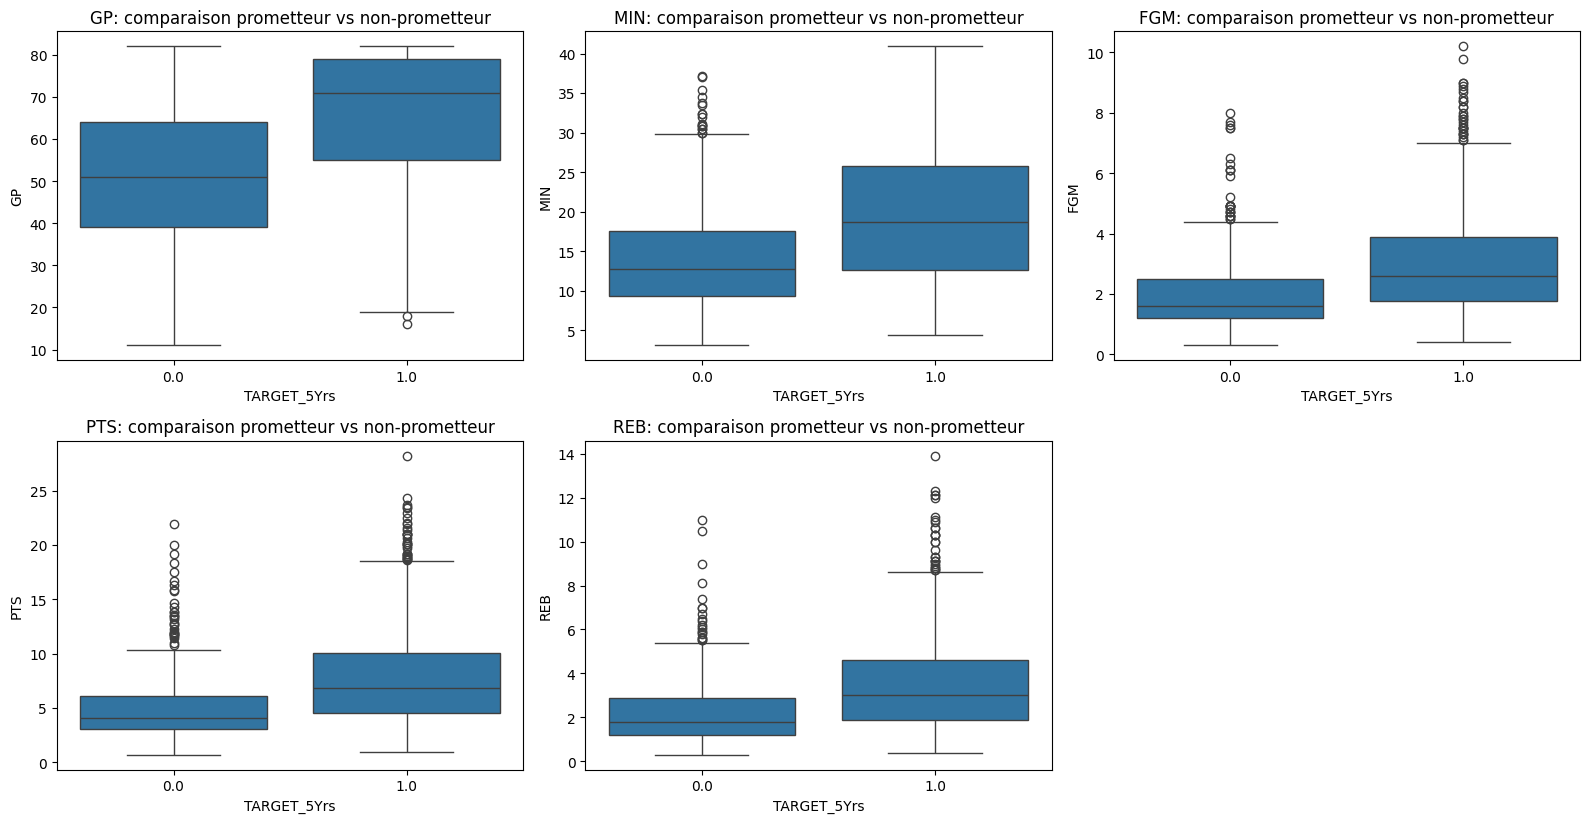

In [56]:
features_to_plot = ["GP", "MIN", "FGM","PTS", "REB"]

plt.figure(figsize=(16, 12))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x="TARGET_5Yrs", y=col, data=df)
    plt.title(f"{col}: comparaison prometteur vs non-prometteur")
plt.tight_layout()
plt.show()


***Interpretation***:

Les boxplots permettent de confirmer visuellement ce que nous avons remarqué dans les matrices de corrélation. 

Les 5 variables permettent de capturer: l'activité offensive, défensive et le rôle dans l'équipe.

- Pour PTS:
Les joueurs prometteurs (TARGET_5Yrs = 1) ont une médiane nettement plus élevée que les non-prometteurs et une distribution plus étalée vers le haut beaucoup plus d’outliers positifs.
Interprétation: Les joueurs capables de marquer régulièrement ont beaucoup plus de chances de durer dans la ligue.


- Pour MIN:
La médiane des prometteurs est située entre 18 et 20 min tandis que celle des non-prometteurs entre 12 et 13 min. Les prometteurs ont des maximums beaucoup plus élevés (entre 30 et 40 min). 
Interprétation: Le temps de jeu est un excellent indicateur de potentiel réel.
Si un joueur obtient plus de minutes, c’est qu’il a gagné la confiance du coach  alors il a plus de chance de rester dans la ligue.


- Pour REB: 
La médiane est plus élevée pour les prometteurs avec une distribution  plus décalée vers la droite. 
Cela indique la présence de nombreux joueurs intérieurs dominants chez les prometteurs. 
Interprétation: Les joueurs qui contribuent physiquement (REB, OREB, DREB) ont davantage un rôle stable, ce qui améliore leur longévité.


- Pour FGM:
La médiane est également plus élevé pour les prometteurs.
Les joeurs prometteurs atteignes des valeurs plus elevé comparé aux non prometteurs. 
Interprétation: Les joueurs avec de bonne capacité de reussite aux tirs ont plus de chance de rester en NBA.

Les boxplots montrent des différences nettes entre les joueurs prometteurs (carrière ≥ 5 ans) et les non-prometteurs. Les prometteurs jouent davantage de minutes, marquent plus de points, prennent plus de rebonds, cela valide l'intuition métier

La visualisation rejoint l’analyse de corrélation : MIN, PTS, REB et les volumes offensifs sont de solides prédicteurs de longévité NBA.


# Analyse bivariée

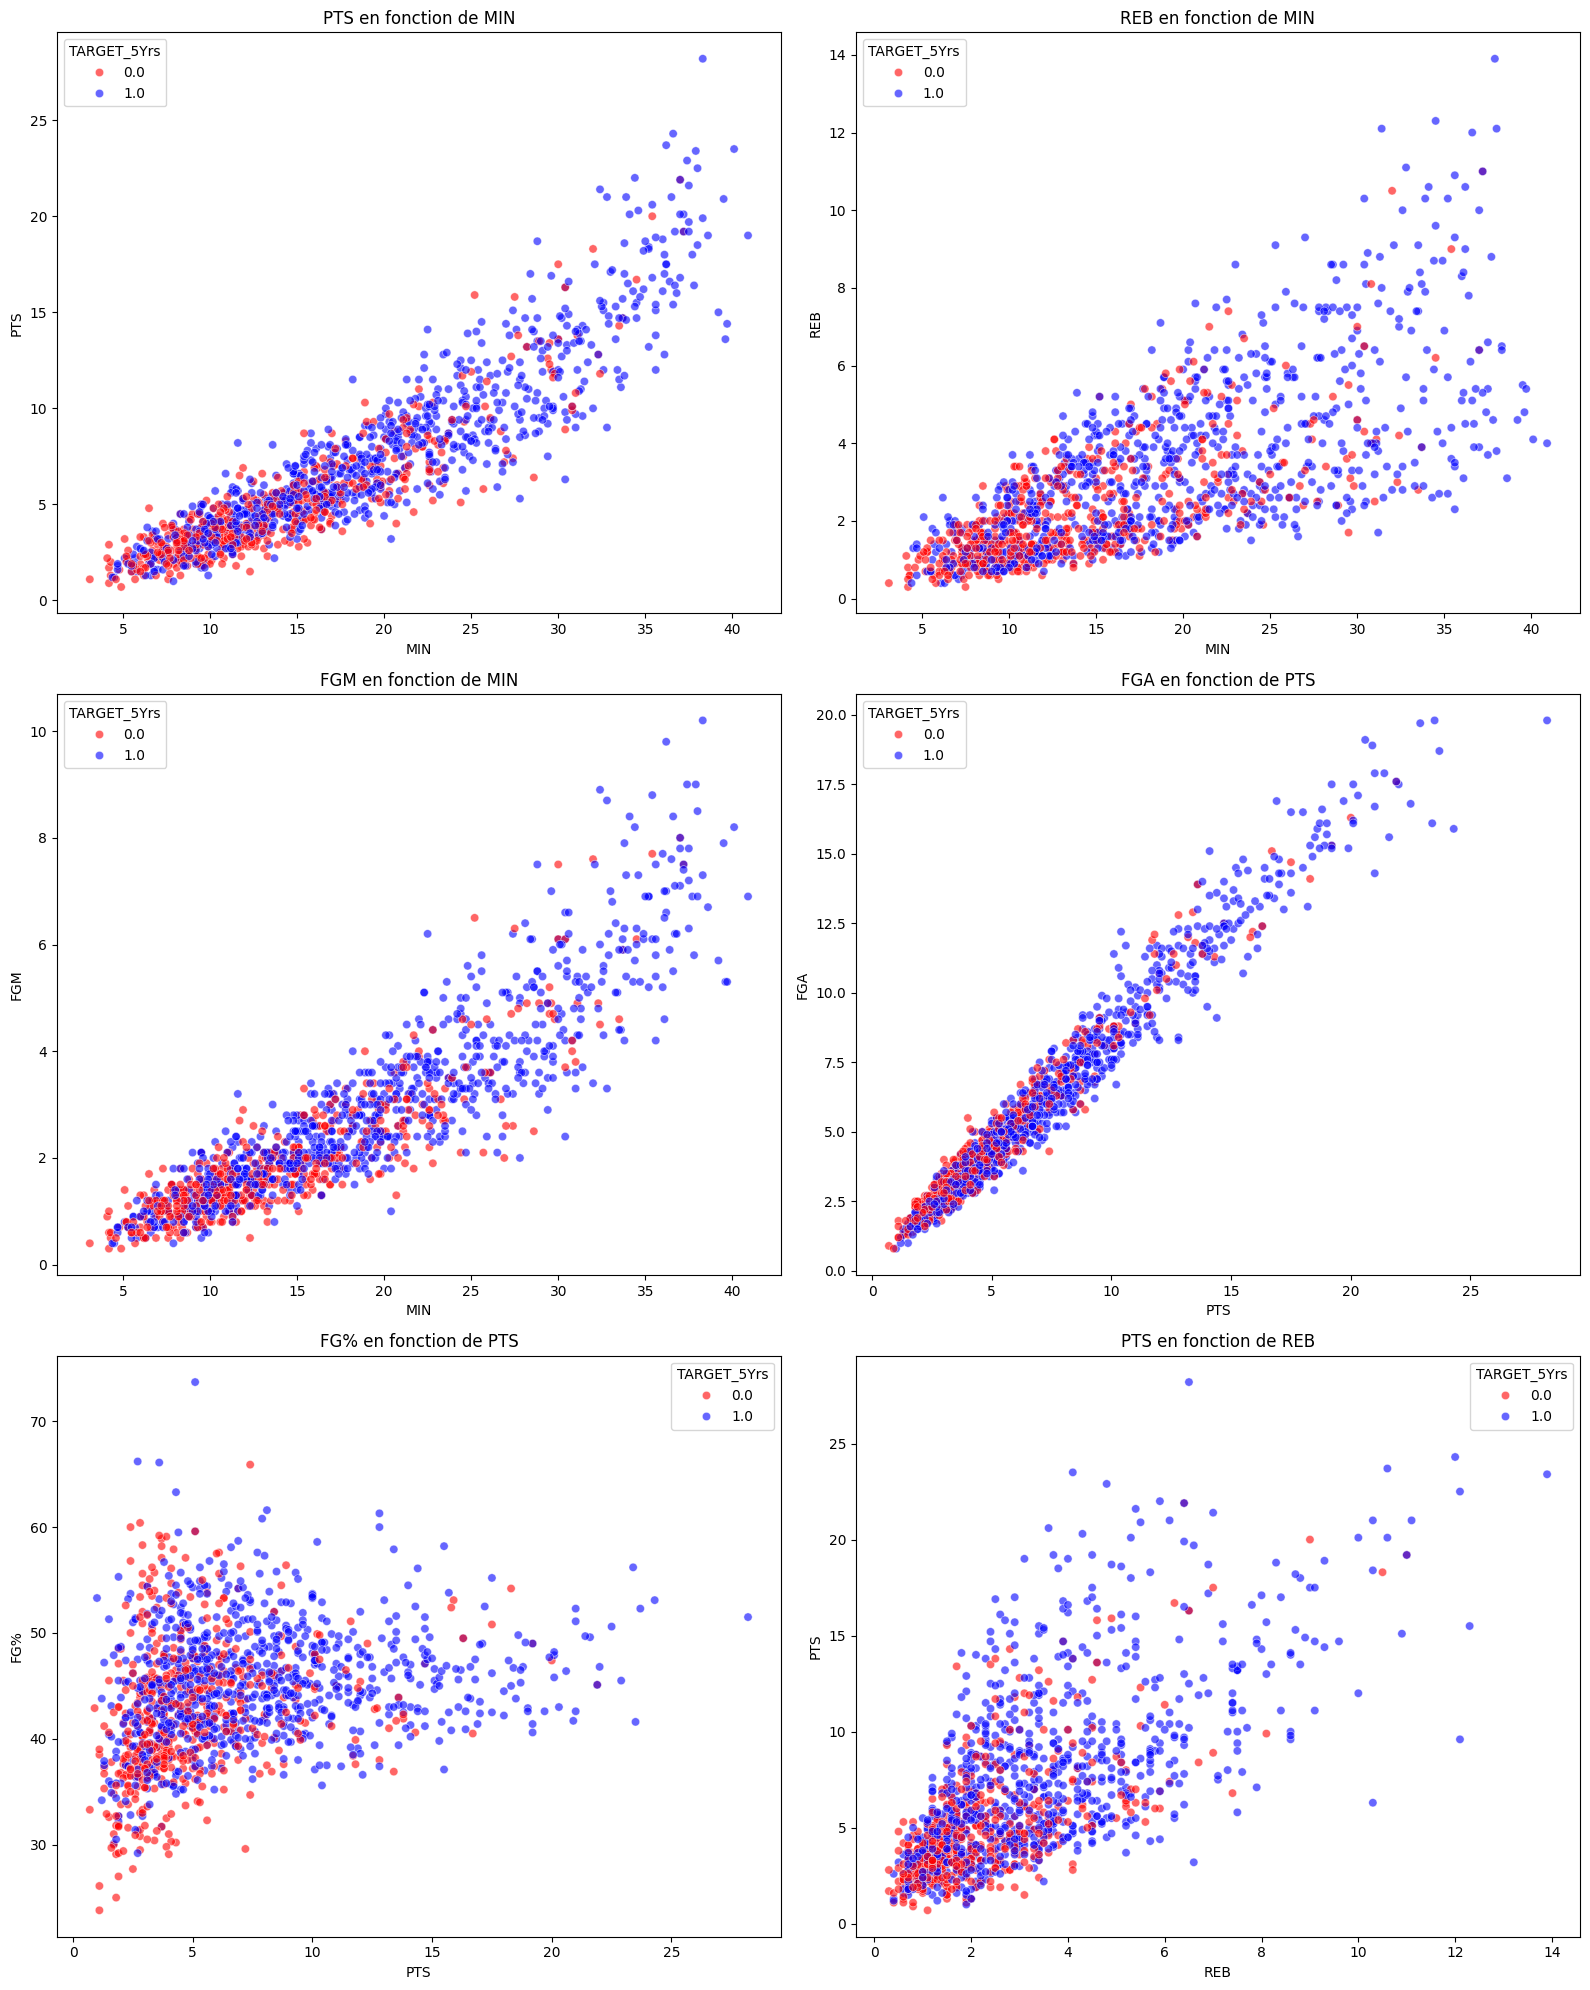

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

pairs = [
    ("MIN", "PTS"),
    ("MIN", "REB"),
    ("MIN", "FGM"),
    ("PTS", "FGA"),
    ("PTS", "FG%"),
    ("REB", "PTS")
]

plt.figure(figsize=(16, 20))

for i, (x, y) in enumerate(pairs, 1):
    plt.subplot(3, 2, i)
    sns.scatterplot(data=df, x=x, y=y, hue="TARGET_5Yrs", alpha=0.6, palette=["red", "blue"])
    plt.title(f"{y} en fonction de {x}")

plt.tight_layout()
plt.show()


***Interpretation***:

- PTS en fonction de MIN

Relation quasi linéaire, plus un joueur joue, plus il marque.

Les non-prometteurs (rouge) sont quasiment tous sous 15 minutes et 6 points.

Les prometteurs (bleu) sont dans une zone plus large, jusqu’à 40 min et plus de 25 points.

Interpretation: Le temps de jeu et la production offensive sont des caractéristiques très forts de longévité en NBA.

- REB en fonction de MIN

Relation croissante.

Les non-prometteurs restent très concentrés en bas : MIN < 15, REB < 3.

Les prometteurs s’étendent jusqu’à REB > 10, MIN > 30.

Interpretation: Les joueurs physiquement impactants (rebonds) ont beaucoup plus de chances d’être conservés dans la ligue.

- FGM en fonction de MIN

Similaire au PTS en fonction de MIN

- FGA en fonction de PTS

Relation linéaire.

Les non-prometteurs n'atteignent jamais les hauts volumes de tirs.

Les prometteurs sont présents dans toutes les gammes.

Interpretation: Les joueurs intégrés offensivement avec un volume de tirs suffisant ont une carrière plus durable.

- FG% en fonction de PTS

Pas de séparation visuelle claire.

Les joueurs efficaces ne sont pas forcément ceux qui durent plus longtemps.

Les non-prometteurs peuvent même avoir un bon pourcentage.

L’efficacité au tir (FG%) n’est pas un facteur déterminant pour prédire la longévité NBA.


- PTS en fonction de REB

Les joueurs prometteurs (bleu) occupent tout l'espace supérieur: On peut identifier des joueurs qui realise beaucoup plus de rebonds sans marquer de points, des joueurs qui marquent plus de points sans réaliser de rebons et des joueurs polyvalents. 

Les non-prometteurs sont concentrés sur PTS < 6 et REB < 3


Interpretation: Les joueurs capables d’exceller dans au moins une dimension (scoring ou rebond) ont beaucoup plus de chance de rester dans la ligue.

Conclusion: 

L’analyse bivariée par scatterplots montre que le groupe des joueurs prometteurs occupe un espace de performance beaucoup plus étendu que celui des non-prometteurs. Les non-prometteurs sont fortement concentrés dans les faibles contributions (MIN < 15, PTS < 6, REB < 3), tandis que les prometteurs couvrent la quasi-totalité de l’espace des valeurs élevées.

Le temps de jeu (MIN), le volume offensif (PTS, FGA) et l’impact physique (REB) se révèlent des facteurs discriminants majeurs entre les deux groupes. À l’inverse, l’efficacité au tir (FG%) ne permet pas de distinguer clairement les deux populations.

Cela renforce les remarque faites depuis le debut de l'analyse. 

# ACP

In [15]:

scaler=StandardScaler()
X= df.drop(columns=["TARGET_5Yrs", "Name"])
X_scaled=scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative = explained_var.cumsum()

print("Variance expliquée par composante :")
print(explained_var)

print("\nVariance cumulée :")
print(cumulative)

Variance expliquée par composante :
[5.01262328e-01 2.06178180e-01 6.43977053e-02 4.56088801e-02
 3.93702802e-02 3.11692145e-02 2.62530559e-02 2.35066101e-02
 2.09033606e-02 1.37355760e-02 1.22229687e-02 5.80755112e-03
 5.28549186e-03 2.84986460e-03 7.71362440e-04 4.04227903e-04
 2.44976219e-04 1.94697663e-05 8.89723209e-06]

Variance cumulée :
[0.50126233 0.70744051 0.77183821 0.81744709 0.85681737 0.88798659
 0.91423964 0.93774625 0.95864961 0.97238519 0.98460816 0.99041571
 0.9957012  0.99855107 0.99932243 0.99972666 0.99997163 0.9999911
 1.        ]


***Interpretation***:

La première composante explique 50% de la variance des données. Elle capture la moitié de la structure des données. 
La PC1 et PC2 explique quant à eux 70% de l'information. 
PC1+PC2+PC3 explique 77%, la PC3 ajoute juste 7%. L'information au dela de la PC2 est faible mais utile en visualisation 3D. 
Pour expliquer 90% de la variance, nous avons besoin de 6 composantes, ce qui indique que la structure n'est pas trop complexe.  




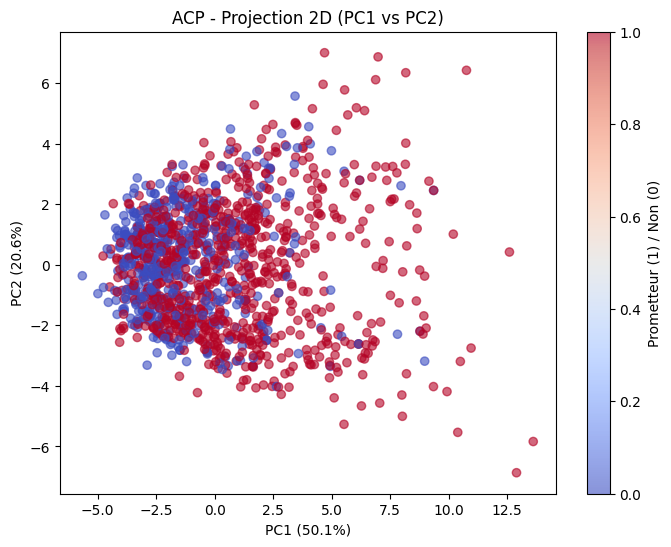

In [16]:
# 2 composantes
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca_2[:, 0], 
    X_pca_2[:, 1], 
    c=df["TARGET_5Yrs"], 
    cmap="coolwarm", 
    alpha=0.6
)

plt.xlabel("PC1 ({}%)".format(round(pca_2.explained_variance_ratio_[0]*100, 1)))
plt.ylabel("PC2 ({}%)".format(round(pca_2.explained_variance_ratio_[1]*100, 1)))
plt.title("ACP - Projection 2D (PC1 vs PC2)")
plt.colorbar(label="Prometteur (1) / Non (0)")
plt.show()


***Interpretation:***

Nous constatons que les deux classes se chevauchent. Il n'y a pas de séparation nette sur ce plan. Bien que la première compossante capture 50% des informations, elle ne permet de séparer les deux classes. La deuxième composante ajoute une nouvelle dimension mais aucune information discriminante.


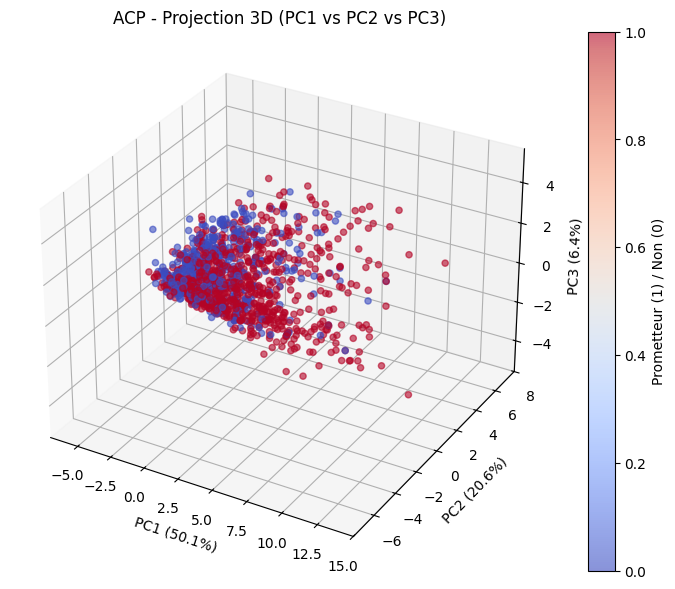

In [17]:
# ACP à 3 composantes
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

# Création du plot 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3[:, 0],
    X_pca_3[:, 1],
    X_pca_3[:, 2],
    c=df["TARGET_5Yrs"],
    cmap="coolwarm",
    alpha=0.6
)

ax.set_xlabel(f"PC1 ({pca_3.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_3.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_3.explained_variance_ratio_[2]*100:.1f}%)")

ax.set_title("ACP - Projection 3D (PC1 vs PC2 vs PC3)")
fig.colorbar(scatter, label="Prometteur (1) / Non (0)")

plt.show()

***Interpretation:***

Avec l'ajout d'une troisième composante pour expliquer 77% de la variance, il n'y a toujours pas de séparation linéaire possible entre les deux classes. 
Cela confirme que la relation entre les statistiques d’un joueur et sa probabilité de durer plus de 5 ans en NBA présente une part importante de non-linéarité et d’interactions implicites entre variables.
Alors pour capturer au mieux la structure des données, un modèle non linéaire serait une meilleure option. 

In [18]:
# Récupération des variables composant la première composante
pc1_loadings = pca.components_[0]

# Converision en df
pc1_contrib = pd.DataFrame({
    "variable": X.columns,
    "contribution_PC1": pc1_loadings
})

# Tri par importance absolue
pc1_contrib = pc1_contrib.reindex(pc1_contrib.contribution_PC1.abs().sort_values(ascending=False).index)

pc1_contrib

,variable,contribution_PC1
2,PTS,0.312867
3,FGM,0.309034
1,MIN,0.308042
4,FGA,0.302535
10,FTA,0.291309
9,FTM,0.291191
18,TOV,0.284166
13,DREB,0.260671
14,REB,0.255476
16,STL,0.236591


***Interpretation***:

La première composante principale (PC1), qui explique à elle seule plus de 50% de la variance du dataset, est dominée par des variables de volume de jeu (minutes, tirs tentés, tirs marqués), de production offensive (points, lancers francs) et d’activité globale (rebonds, balles perdues).

PC1 représente donc un axe impact global et l'utilisation offensive, opposant les joueurs très utilisés et productifs aux joueurs faiblement impliqués.


# Features enginnering

Nous avons des données mésurant la performance des joueurs au cours d'une saison, évalué en moyenne par match. Cela reflète la capacité global du joueur mais pas sont éfficacité. Par exemple un joueur qui marque environ 30 points par macth ne nous dit pas combien de tirs il a tenté ou scorer en une minute. Ajouter des features pour déterminer l'éfficacité des joeurs serait peut être un plus. De plus, certains joueurs ont moins de temps de jeu mais sont plus pertinents.

In [19]:
df_augmented=df.copy()
eps = 1e-6  # pour éviter les divisions par zéro
# Efficacité offensive
df_augmented["FG_eff"] = df_augmented["FGM"] / (df_augmented["FGA"] + eps) # Efficacité des tirs
df_augmented["3P_eff"] = df_augmented["3P Made"] / (df_augmented["3PA"] + eps) # Efficacité des 3P
df_augmented["FT_eff"] = df_augmented["FTM"] / (df_augmented["FTA"] + eps) # Efficacité Lancers francs

# Impact par minute
df_augmented["PTS_ratio"] = df_augmented["PTS"] / (df_augmented["MIN"] + eps) # Points marqués par minute
df_augmented["REB_ratio"] = df_augmented["REB"] / (df_augmented["MIN"] + eps) # Rebonds par minute
df_augmented["AST_ratio"] = df_augmented["AST"] / (df_augmented["MIN"] + eps) # Passes dé par minute
df_augmented["STL_ratio"] = df_augmented["STL"] / (df_augmented["MIN"] + eps) # Interceptions par minute
df_augmented["BLK_ratio"] = df_augmented["BLK"] / (df_augmented["MIN"] + eps) # Blocage par minute
df_augmented["TOV_ratio"] = df_augmented["TOV"] / (df_augmented["MIN"] + eps) # Perte de bal par minute

# Role offensif
df_augmented["Usage_proxy"] = (df_augmented["FGA"] + df_augmented["FTA"] + df_augmented["TOV"]) / (df_augmented["MIN"] + eps)


In [20]:
# Top variables corrélées avec la cible
corr_augmented=df_augmented.corr(numeric_only=True)
corr_cible_augmented=corr_augmented["TARGET_5Yrs"].sort_values(ascending=False)
corr_cible_augmented

TARGET_5Yrs    1.000000
GP             0.396833
MIN            0.317805
FGM            0.317594
PTS            0.315981
REB            0.299406
FTM            0.296841
FTA            0.296089
OREB           0.293307
FGA            0.292660
DREB           0.284677
TOV            0.272348
STL            0.229811
FG%            0.227134
FG_eff         0.223112
BLK            0.210114
PTS_ratio      0.194486
AST            0.175353
REB_ratio      0.137114
Usage_proxy    0.110653
FT%            0.106706
BLK_ratio      0.105939
FT_eff         0.094647
3P Made        0.036619
TOV_ratio      0.018417
3PA            0.018110
AST_ratio      0.017252
STL_ratio      0.003148
3P%           -0.000004
3P_eff        -0.033866
Name: TARGET_5Yrs, dtype: float64

***Interpretation:***

On peut constater que les nouvelles variables n'ont pas de forte corrélation avec la cible. Aucune d'elle ne dépassent 0.22.

On peut donc dire que les joueurs qui durent en NBA ne sont pas forcement les plus éfficaces. 

Les features dérivées basées sur l'efficacité (FG_eff, FT_eff), les ratios par minute (PTS_ratio, REB_ratio) ou le rôle offensif (Usage_proxy) présentent des corrélations modestes avec la longévité.
Cela indique que la longévité en NBA dépend principalement des volumes de jeu (MIN, GP, FGA, REB), plutôt que de l’efficacité pure.
Cependant, ces nouvelles features restent importantes dans un modèle non linéaire (Random Forest, XGBoost) car elles capturent des interactions complexes et permettent de distinguer des profils efficaces ou sous-utilisés, ce que les variables brutes ne peuvent pas révéler seules.

# Séparation des données

In [77]:
# extract names, labels, features names and values
names = df['Name'].values.tolist() # players names
labels = df['TARGET_5Yrs'].values # labels
paramset = df.drop(['TARGET_5Yrs','Name'],axis=1).columns.values
# df_vals = df.drop(['TARGET_5Yrs','Name'],axis=1).values
features=df.drop(['TARGET_5Yrs','Name'],axis=1)
paramset_augmented = df_augmented.drop(['TARGET_5Yrs','Name'],axis=1).columns.values
# df_vals_augmented = df_augmented.drop(['TARGET_5Yrs','Name'],axis=1).values
features_augmented=df_augmented.drop(['TARGET_5Yrs','Name'],axis=1)

(1328,)

# Entrainnement des base line modèles

D'après nos analyses statistiques et différents graphiques, nous pouvons tester un modèle linéaire, car nous avons constater que la longévité d'un joueur dépend de ses aptitude physique, attaque, déffensive et son implication dans le jeu. Plus ses stats sont élevées plus le joueurs dure dans la ligue. 
Nous avons également constater que les valeurs médianes de ces variables sont plus élevé chez les joueurs prometteurs. Ces remarque sont renforcé par la première composante de l'ACP. 

Cependant, les modèles linéaires ne permettent pas de capturer les intéractions (l'effet des différentes variables sur les autres) entre les variables et la non-linéarité. Nous allons donc comparer les performance de notre modèle de base à d'autre modèles non linéaires.  

Afin d'évaluer l'influence des nouvelles variables sur les performances des modèles, nous allons donc entrainné nos modèles avec les données de bases et les données augmentées, bien que nous ayons constater qu'ils n'ont pas de forte corrélation avec la cible. 

Pour départager nos modèles nous allons ténir compte de certaines métriques, celles qui sont plus importantes pour notre cas.
En effet, l'objectif est de détecter les joeurs prometteurs et éviter au maximum de passer à côté d'eux. Nous allons donc minimiser les Faux négatifs et essayé d'avoir un recall assez élevé pour la classe 1 (joueur avec une carrière supérieure à 5 ans), c'est a dire détecter le plus possible les joeurs prometteurs.
Prédire également de manière fiable qu'un joueur est prometteur (un bon ROC-AUC).
Réduire les paris risqués sur des joeurs non prometteurs (avoir une bonne précision). D'ou la fonction d'evaluation ci dessous (score_classifier) 


***Fonction d'évaluation (score_classifier):***

Cette fonction réalise une séparation des données en ensemble d'entrainnement (80%) et en ensemble de test(20%) des données en utilisant une stratification basée sur la variable cible TARGET_5Yrs. Cela garantit que la proportion de joueurs prometteurs et non-prometteurs est conservée dans les deux ensembles, évitant tout biais de distribution et le paramètre random_state=42 assure la reproductibilité des expériences.

Elle retourne après entrainnement :
- Le rapport de classification: Donne les performances du modèle sur les différentes classes
- La matrice de confusion: Donne un tableau regroupant les bonnes et mauvaises prédictions par classe
- Le socre ROC-AUC: Indique la qualité globale du modèle

In [58]:
# Fonction d'évaluation
def score_classifier(dataset,classifier,labels):

    """
    performs a training/test to build a confusion matrix, prints results with precision and ROC-AUC scores
    :param dataset: the dataset to work on
    :param classifier: the classifier to use
    :param labels: the labels used for training and validation
    :return:
    """

    training_set,test_set,training_labels,test_labels=train_test_split(dataset,labels,test_size=0.2,random_state=42,stratify=labels)
    classifier.fit(training_set, training_labels)
    predicted_labels = classifier.predict(test_set)
    labels_proba = classifier.predict_proba(test_set)[:, 1]
    print("Classification Report:\n", classification_report(test_labels, predicted_labels))
    print("Confusion Matrix:\n", confusion_matrix(test_labels, predicted_labels))
    print("ROC-AUC:", roc_auc_score(test_labels, labels_proba))

In [ ]:
# Regression logistique
pipe_logReg = Pipeline([
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
        solver="saga",
        n_jobs=-1
    ))
])

print("Regression logistique avec les données normales:")
score_classifier(features,pipe_logReg,labels)
print("\n")
print("Regression logistique avec les données augmentées:")
score_classifier(features_augmented,pipe_logReg,labels)


Regression logistique avec les données normales:
Classification Report:
               precision    recall  f1-score   support

         0.0       0.60      0.73      0.66       102
         1.0       0.81      0.70      0.75       166

    accuracy                           0.71       268
   macro avg       0.70      0.72      0.71       268
weighted avg       0.73      0.71      0.72       268

Confusion Matrix:
 [[ 74  28]
 [ 49 117]]
ROC-AUC: 0.7661823765650838


Regression logistique avec les données augmentées:
Classification Report:
               precision    recall  f1-score   support

         0.0       0.60      0.71      0.65       102
         1.0       0.80      0.71      0.75       166

    accuracy                           0.71       268
   macro avg       0.70      0.71      0.70       268
weighted avg       0.72      0.71      0.71       268

Confusion Matrix:
 [[ 72  30]
 [ 48 118]]
ROC-AUC: 0.767363571934798


***Interpretation***:

La regression logistique a de bonnes performance, avec un recall à 0.7 et une precision de 0.81 sur les joueurs prometteurs. L'air sous la courbe ROC qui évalue la qualité globale du classifier est également acceptable. 

Par contre nous pouvons constater que les nouvelles variables n'influencent presque pas les performances du modèle.



## Random Forest

In [24]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Random Forest avec les données normales: ")
score_classifier(features,rf,labels)
print("\n")
print("Random Forest avec les données augmentées:")
score_classifier(features_augmented,rf,labels)

Random Forest avec les données normales: 
Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.57      0.61       102
         1.0       0.76      0.82      0.79       166

    accuracy                           0.72       268
   macro avg       0.71      0.69      0.70       268
weighted avg       0.72      0.72      0.72       268

Confusion Matrix:
 [[ 58  44]
 [ 30 136]]
ROC-AUC: 0.7391625324828727


Random Forest avec les données augmentées:
Classification Report:
               precision    recall  f1-score   support

         0.0       0.63      0.55      0.59       102
         1.0       0.74      0.80      0.77       166

    accuracy                           0.71       268
   macro avg       0.69      0.68      0.68       268
weighted avg       0.70      0.71      0.70       268

Confusion Matrix:
 [[ 56  46]
 [ 33 133]]
ROC-AUC: 0.7433262461611151


***Interprétation:***

Le Random Forest, présente également de bonnes performances avec un recall de 0.82 et une precision de 0.76 sur la classe de joueurs prometteurs. Cependant il est moins bon sur la détection des joueurs non-prometteurs. 

Nous pouvons également constater que les données augmentées n'influence pas non plus grandement les performances du modèle

## XGBoost

In [25]:
xgb= XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=509/831,  # ratio des classes (non_prometteur / prometteur)
    random_state=42
)

print("XGBoost avec les données normales: ")
score_classifier(features,xgb,labels)
print("\n")
print("XGBoost avec les données augmentées:")
score_classifier(features_augmented,xgb,labels)

XGBoost avec les données normales: 
Classification Report:
               precision    recall  f1-score   support

         0.0       0.61      0.69      0.65       102
         1.0       0.79      0.73      0.76       166

    accuracy                           0.71       268
   macro avg       0.70      0.71      0.70       268
weighted avg       0.72      0.71      0.72       268

Confusion Matrix:
 [[ 70  32]
 [ 45 121]]
ROC-AUC: 0.7587999055043705


XGBoost avec les données augmentées:
Classification Report:
               precision    recall  f1-score   support

         0.0       0.58      0.55      0.57       102
         1.0       0.73      0.76      0.75       166

    accuracy                           0.68       268
   macro avg       0.66      0.65      0.66       268
weighted avg       0.68      0.68      0.68       268

Confusion Matrix:
 [[ 56  46]
 [ 40 126]]
ROC-AUC: 0.7404913772738011


***Interprétation:***

Le XGBoost présente également des performances acceptables avec un recall à 0.71 et une précision à 0.79 sur la classe de joueurs prometteurs, une aire sous la courbe à 0.75. 

L’ajout des nouvelles variables n’apporte pas d’amélioration significative, probablement parce que les features ajoutées sont fortement corrélées à celles déjà présentes, ou redondantes. Le modèle extrait déjà l’essentiel de l’information à partir des variables brutes.

***Conclusion:***

En comparaison, la regression logistique est le modèle le plus performant globalement (ROC-AUC:0.76), suivi du XGBosst (ROC-AUC:0.75), puis du RF (ROC-AUC:0.73).

Le Random Forest est celui qui détecte le mieux les joueurs prometteurs (recall = 0.82), ce qui correspond exactement à notre besoin métier.
XGBoost suit avec 0.76, puis la régression logistique (0.70)

Le Random Forest est donc le meilleur compromis entre détection des joueurs prometteurs, stabilité du modèle et cohérence métier.

# Optimisation des modèles

Nous allons optimiser nos modèles afin de voir si le random forest conserve son avantage. 

Vu que données augmentées n'influencent pas grandement les performances des modèles, nous allons nous focaliser sur les données normales.

In [59]:
from scipy.stats import loguniform, uniform

param_dist_logReg = {
    "model__C": loguniform(1e-3, 1e3),          # C entre 0.001 et 1000
    "model__penalty": ["l1", "l2", "elasticnet"],
    "model__l1_ratio": uniform(0, 1),           
    "model__class_weight": [None, "balanced"]
}

logReg_search = RandomizedSearchCV(
    estimator=pipe_logReg,
    param_distributions=param_dist_logReg,
    n_iter=50,                
    scoring="roc_auc",          
    cv=5,
    n_jobs=-1,
    # verbose=2,
    random_state=42
)


print("Regression logistique avec RandomizedSearch:")
score_classifier(features,pipe_logReg,labels)


Regression logistique avec RandomizedSearch:
Classification Report:
               precision    recall  f1-score   support

         0.0       0.60      0.73      0.66       102
         1.0       0.81      0.70      0.75       166

    accuracy                           0.71       268
   macro avg       0.70      0.72      0.71       268
weighted avg       0.73      0.71      0.72       268

Confusion Matrix:
 [[ 74  28]
 [ 49 117]]
ROC-AUC: 0.7661823765650838


In [61]:
param_dist_rf = {
    "n_estimators": [200, 300, 400, 500, 600],
    "max_depth": [None, 6, 8, 10, 12, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", {0:1, 1:1.2}, {0:1, 1:1.5}]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=30,                # 30 essais → suffisant
    scoring="roc_auc",        # métrique centrale
    cv=5,
    # verbose=2,
    random_state=42,
    n_jobs=-1
)

print("Random Forest avec RandomizedSearch:")


score_classifier(features,rf,labels)


Random Forest avec RandomizedSearch:
Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.57      0.61       102
         1.0       0.76      0.82      0.79       166

    accuracy                           0.72       268
   macro avg       0.71      0.69      0.70       268
weighted avg       0.72      0.72      0.72       268

Confusion Matrix:
 [[ 58  44]
 [ 30 136]]
ROC-AUC: 0.7391625324828727


In [62]:
param_dist_xgb = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.8, 1],
    "colsample_bytree": [0.6, 0.8, 1],
    "scale_pos_weight": [0.5, 0.75, 1, 1.25]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    # verbose=2,
    random_state=42,
    n_jobs=-1
)

print("XGBoost avec RandomizdSearch")
score_classifier(features,xgb_search,labels)

XGBoost avec RandomizdSearch
Classification Report:
               precision    recall  f1-score   support

         0.0       0.72      0.46      0.56       102
         1.0       0.73      0.89      0.80       166

    accuracy                           0.73       268
   macro avg       0.73      0.68      0.68       268
weighted avg       0.73      0.73      0.71       268

Confusion Matrix:
 [[ 47  55]
 [ 18 148]]
ROC-AUC: 0.7722655327191116


***Interpretation:***

Après optimisation des modèles, Nous constatons que les trois modèles ont de bonnes performances pour la reconnaissance des joueurs prometteurs avec un léger avantage pour le XGBoost qui a un meilleur recall sur la classe 1. Sa détection des joueurs non prometteurs ainsi  que sa precision sur cette classe est aussi acceptable. 
De plus, de façon global il a un  meilleur score ROC-AUC comparé aux autres. Nous allons donc retenir le XGBoost comme modèle final.

# Gridsearch sur le meilleur modèle

Pour l'otpimisation des modèles, nous avons utiliser le randomizedsearch afin de réaliser une recherche plus globale sur les meilleurs hyperparamètres. Maintenant que nous avons obtenu les meilleurs hyperparamètres de façon globale, nous allons essayer d'effectuer une recherche plus ciblé autour des meilleurs hyperpamètres afin de voir si nous obtenons de meilleures performances.

In [63]:
param_grid_xgb = {
    "n_estimators": [350, 400, 450],
    "learning_rate": [0.005, 0.01, 0.02],
    "max_depth": [2, 3, 4],
    "min_child_weight": [3, 5, 7],
    "gamma": [0.05, 0.1, 0.2],
    "subsample": [0.5, 0.6, 0.7],
    "colsample_bytree": [0.5, 0.6, 0.7],
    "scale_pos_weight": [1.0, 1.25, 1.5]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring="roc_auc",
    cv=5,
    # verbose=2,
    n_jobs=-1
)


print("XBG avec Grid Search")
score_classifier(features,grid_xgb,labels)


XBG avec Grid Search
Classification Report:
               precision    recall  f1-score   support

         0.0       0.72      0.43      0.54       102
         1.0       0.72      0.90      0.80       166

    accuracy                           0.72       268
   macro avg       0.72      0.66      0.67       268
weighted avg       0.72      0.72      0.70       268

Confusion Matrix:
 [[ 44  58]
 [ 17 149]]
ROC-AUC: 0.7718521143397118


***Interpretation:***

Nous constatons une légère amélioration du recall de la classe 1 au détriement de la precision. La qualité globale du modèle est légèrement reduite.
Pour un meilleur compromis, nous conserverons le modèle obtenu avec les meilleurs hyperparamètres du randomizedsearch qui conserve de meilleures performances pour la reconnaissance des joueurs non prometteurs en plus d'avoir le meilleur ROC-AUC. 

# Explicabilité 

Maintenant que nous avons notre modèle final, nous allons chercher à comprendre sur quelles variables il se base pour classer les joueurs. Pour cela, nous allons utiliser SHAP qui est une méthode d'explicabilité basée sur les valeurs de Shapley. SHAP nous permettra de comprendre à quel point chaque variable pousse une prediction vers prometteur ou vers non-prometteur.

In [64]:
Xtrain, Xtest, ytrain, ytest = train_test_split (features,labels,train_size=0.8, random_state=42, stratify=labels)

(1072, 19)

In [65]:
# Definition de l'explainer
explainer = shap.TreeExplainer(xgb_search.best_estimator_)
shap_values = explainer.shap_values(Xtest)

In [ ]:
# Prediction moyenne du modèle (probabilité qu'il soit prometteur)
explainer.expected_value

np.float32(0.7223064)

***Interpretation:***

Cela nous indique le niveau de base de probabilité qu'un joueur présent dans le dataset soit prometteur. Cette valeur sera alors majoré ou reduit en fonction des capacités de chaque joueur.

Nous allons maintenant analyser quels facteurs influencent le plus la longévité d’un joueur en NBA, selon notre modèle XGBoost.

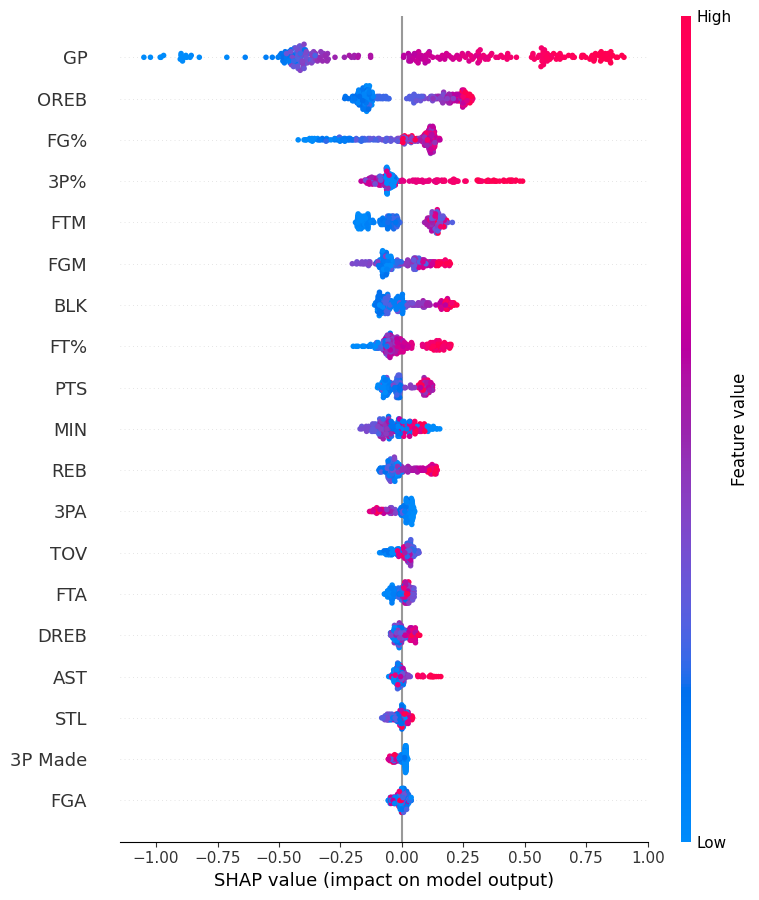

In [66]:
# important pour que les plots s'affichent bien dans certains notebooks
shap.initjs()

# Contribution de chaque variable dans la prediction de la longevité d'un joueur en NBA
shap.summary_plot(shap_values, Xtest, show=True)


***Interpretation:*** 

Nous constatons que les variables utilisées par XGBoost, rejoingne nos constat depuis le début. Les variables les plus importantes sont celle qui indiquent le volume de jeux, les capacité offensives et defensives du joeur avec une prédominance du nombre de match joué.

In [ ]:
# i = 5   # index du joueur
# x_i = Xtest.iloc[i]
# shap_i = shap_values[i]
# shap.force_plot(
#     explainer.expected_value,
#     shap_values[i],
#     Xtest.iloc[i],
#     matplotlib=True
# )


# Features selection

Maintenance que nous connaissons les variables utilisées par le XGBoost pour la prédiction de la longevité des joueurs en NBA, nous allons retenir uniquement les plus importantes pour notre modèle final, en restant vigilant sur la variation des performances.
Pour cela nous allons calculer la contribution moyenne de chaque variable et retenir les 10 premières.

In [67]:
# Moyenne de la valeur absolue des SHAP values sur le test
shap_importance = np.mean(np.abs(shap_values), axis=0)

feature_importance = pd.DataFrame({
    "feature": Xtest.columns,
    "mean_abs_shap": shap_importance
})

# Trie de la plus importante à la moins importante
feature_importance = feature_importance.sort_values("mean_abs_shap", ascending=False)
feature_importance


,feature,mean_abs_shap
0,GP,0.448600
12,OREB,0.168445
5,FG%,0.128452
8,3P%,0.119914
9,FTM,0.119772
3,FGM,0.079615
17,BLK,0.077114
11,FT%,0.071447
2,PTS,0.062200
1,MIN,0.060881


In [71]:
# Puissance d'explicabilité
sum_top11 = feature_importance.mean_abs_shap.iloc[:11].sum()
sum_total = feature_importance.mean_abs_shap.sum()
sum_top11 / sum_total

np.float32(0.87591034)

***Interpretation:***

Avec les 10 première variable nous 83% d'explicabilité, mais en ajoutant la 11ème variable nous avons 87% d'explicabilité.
Nous allons donc réentrainé notre modèle avec ces variables et analyser les performances.

In [80]:
# Liste des onzes variables plus importantes
selected_features = ["GP","OREB","FG%","3P%","FTM","FGM","BLK","FT%","MIN","PTS","REB"]

In [81]:
# Modèle avec les meilleurs hyperparamètres
xgb_light = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    **xgb_search.best_params_
)

print("XGBoost light")
score_classifier(df[selected_features],xgb_light,labels)

XGBoost light
Classification Report:
               precision    recall  f1-score   support

         0.0       0.66      0.41      0.50       101
         1.0       0.71      0.87      0.78       165

    accuracy                           0.70       266
   macro avg       0.68      0.64      0.64       266
weighted avg       0.69      0.70      0.68       266

Confusion Matrix:
 [[ 41  60]
 [ 21 144]]
ROC-AUC: 0.7414341434143414


***Interpretation:***

Le modèle final XGBoost (11 features) atteint un recall de 0.87 pour les joueurs prometteurs, avec un ROC-AUC de 0.74.
Ces performances sont suffisantes pour un outil d'aide à l’investissement, permettant d’identifier précocement des joueurs ayant un potentiel de longévité en NBA.

L’application finale repose sur un pipeline reproductible et un modèle optimisé, prêt à être intégré dans une API (fastAPI) ou une interface utilisateur (Streamlit).


***Conclusion:***

Le modèle final XGBoost réduit à 11 variables obtient un recall de 0.87 sur les joueurs prometteurs, avec un ROC-AUC de 0.74, des performances légèrement inférieures au modèle complet, mais étant plus léger et plus explicable.

Le pipeline mis en place permet :

- une sélection rigoureuse des features via SHAP,
- une optimisation des hyperparamètres,
- une interprétabilité claire,
- une préparation facile pour un déploiement API ou Streamlit.

Ce modèle constitue une base fiable pour aider des investisseurs à identifier les joueurs ayant le plus de chances de s’installer durablement en NBA.

 # Sauvegarde du modèle final

In [82]:
joblib.dump(xgb_light, "xgb_final.pkl")


['xgb_final.pkl']